In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def least_squares(x, y):
    n = len(x)
    m = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - m * np.sum(x)) / n
    return m, b

In [3]:
np.random.seed(42)
x_rand = np.sort(np.random.rand(20))
y_rand = np.random.rand(20)
m_custom, b_custom = least_squares(x_rand, y_rand)
np_rand = np.polyfit(x_rand, y_rand, 1)

print("Random Vector Test")
print(f"Custom: m={m_custom:.4f}, b={b_custom:.4f}")
print(f"NumPy: m={np_rand[0]:.4f}, b={np_rand[1]:.4f}\n")

Random Vector Test
Custom: m=0.1273, b=0.3966
NumPy: m=0.1273, b=0.3966



In [4]:
TRUE_M, TRUE_B = 10, 1
x = np.arange(0, 1.01, 0.01)
y = TRUE_M * x + TRUE_B + np.random.uniform(0, 1, len(x))

In [5]:
m_c, b_c = least_squares(x, y)
np_coeffs  = np.polyfit(x, y, 1)
m_np, b_np = np_coeffs

print("Linear Data (y = 10x + 1 ± noise)")
print(f"True equation: y = {TRUE_M}x + {TRUE_B}")
print(f"Custom: y = {m_c:.4f}x + {b_c:.4f}")
print(f"NumPy polyfit: y = {m_np:.4f}x + {b_np:.4f}\n")

Linear Data (y = 10x + 1 ± noise)
True equation: y = 10x + 1
Custom: y = 10.0645x + 1.4615
NumPy polyfit: y = 10.0645x + 1.4615



In [6]:
y_pred = m_c * x + b_c
residuals = y - y_pred

print("Residuals (first 5 shown)")
for i in range(5):
    print(f"x={x[i]:.2f}  y={y[i]:.4f}  ŷ={y_pred[i]:.4f}  res={residuals[i]:+.4f}")

max_idx = np.argmax(np.abs(residuals))
min_idx = np.argmin(np.abs(residuals))
print(f"\n  Largest  residual → index {max_idx}, x={x[max_idx]:.2f}, residual={residuals[max_idx]:+.4f}")
print(f"  Smallest residual → index {min_idx}, x={x[min_idx]:.2f}, residual={residuals[min_idx]:+.4f}")

Residuals (first 5 shown)
x=0.00  y=1.1220  ŷ=1.4615  res=-0.3395
x=0.01  y=1.5952  ŷ=1.5622  res=+0.0330
x=0.02  y=1.2344  ŷ=1.6628  res=-0.4284
x=0.03  y=2.2093  ŷ=1.7634  res=+0.4459
x=0.04  y=1.6588  ŷ=1.8641  res=-0.2053

  Largest  residual → index 88, x=0.88, residual=-0.5113
  Smallest residual → index 55, x=0.55, residual=-0.0032


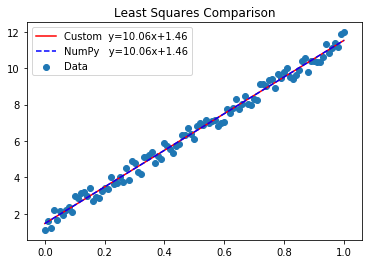

In [11]:
plt.scatter(x, y, label="Data")
plt.plot(x, m_c * x + b_c,   color="red", label=f"Custom  y={m_c:.2f}x+{b_c:.2f}")
plt.plot(x, m_np * x + b_np, color="blue", linestyle="--", label=f"NumPy   y={m_np:.2f}x+{b_np:.2f}")
plt.legend()
plt.title("Least Squares Comparison")
plt.show()